IMPORT

In [ ]:
import os
import torch
import torchvision
import pandas as pd
import torch.nn as nn
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Load and check dataset

In [3]:
train_df = pd.read_csv("fairface-label-train.csv")
val_df = pd.read_csv("fairface-label-val.csv")
print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("\nColumns:")
print(train_df.columns)
print("\nMissing values:")
print(train_df.isnull().sum())
print("\nRace statistics:")
print(train_df["race"].describe())

Train shape: (86744, 5)
Validation shape: (10954, 5)

Columns:
Index(['file', 'age', 'gender', 'race', 'service_test'], dtype='str')

Missing values:
file            0
age             0
gender          0
race            0
service_test    0
dtype: int64

Race statistics:
count     86744
unique        7
top       White
freq      16527
Name: race, dtype: object


Distribution

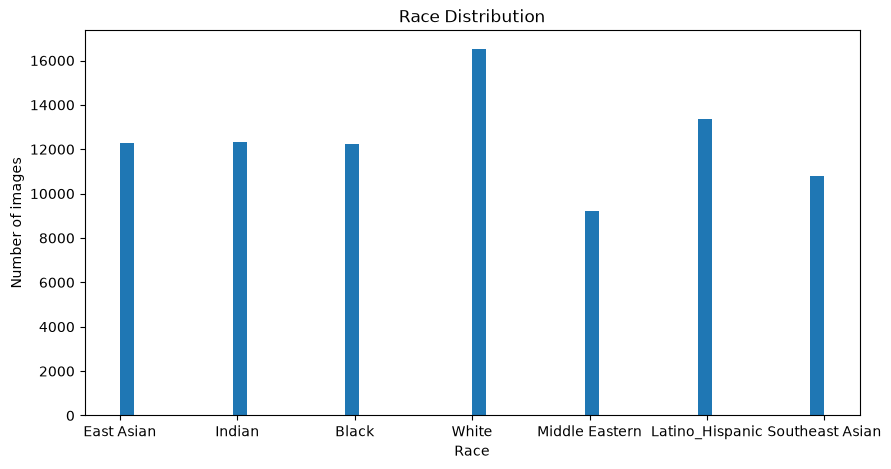

In [4]:
plt.figure(figsize=(10, 5))
plt.hist(train_df["race"], bins=50)
plt.xlabel("Race")
plt.ylabel("Number of images")
plt.title("Race Distribution")
plt.show()

check the dataset and images are mach

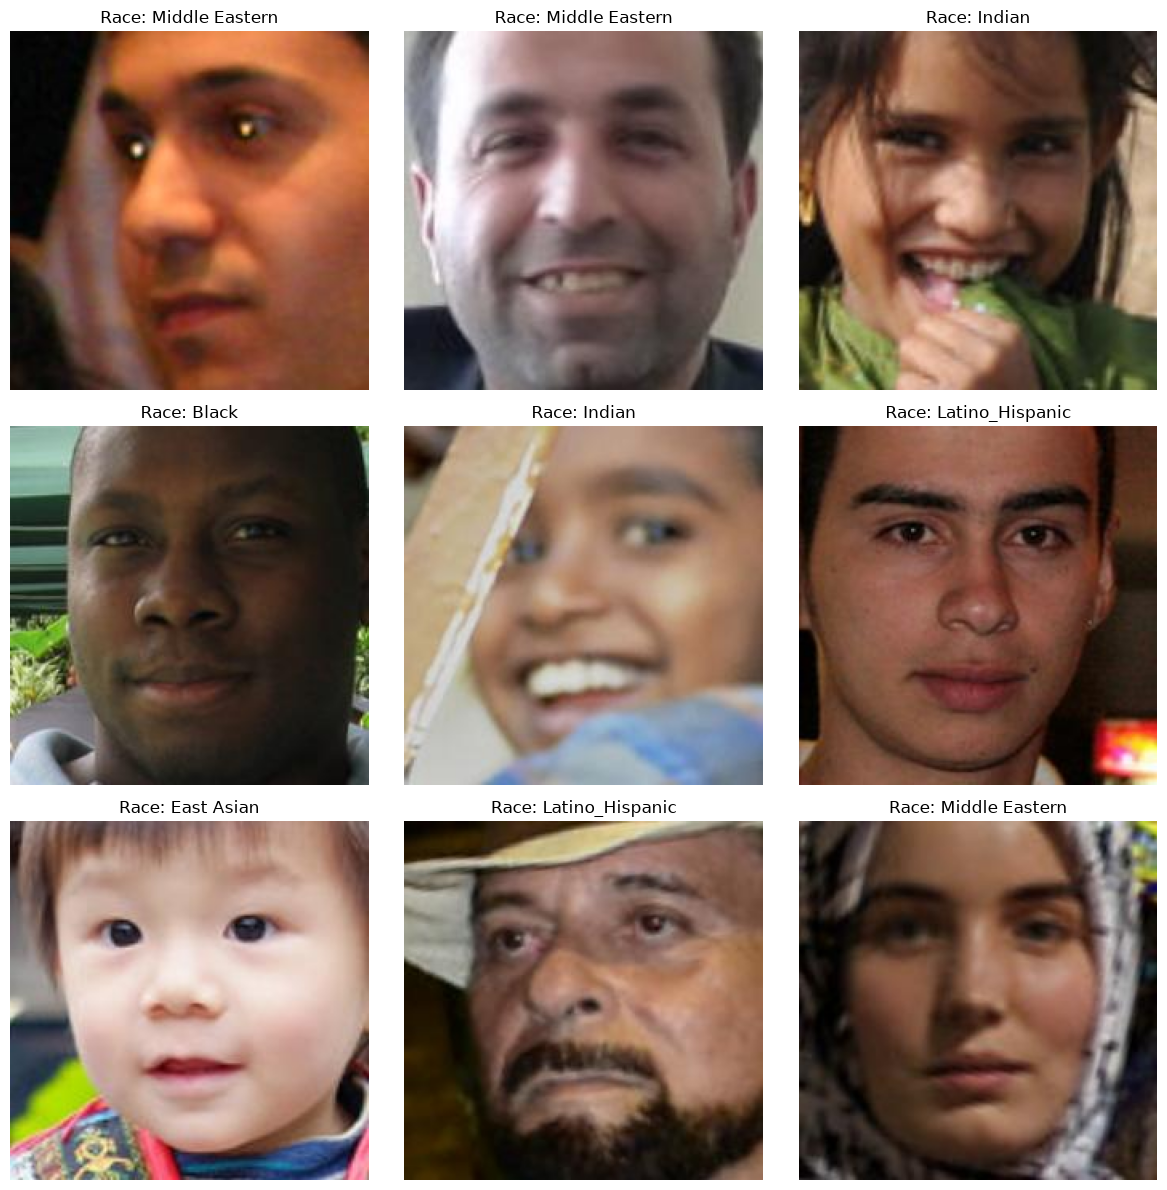

In [5]:
samples = train_df.sample(9, random_state=42)
plt.figure(figsize=(12, 12))
for i, (_, row) in enumerate(samples.iterrows()):
    image_path = row["file"]
    image = Image.open(image_path)
    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(f"Race: {row['race']}")
    plt.axis("off")
plt.tight_layout()
plt.show()

check images size

In [9]:
image_sizes = []
for _, row in train_df.sample(1000, random_state=42).iterrows():
    image_path = row["file"]
    try:
        with Image.open(image_path) as image:
            image_sizes.append(image.size)
    except Exception as e:
        print(f"Error reading {image_path}: {e}")
size_counts = Counter(image_sizes)
print("Number of different image sizes:", len(size_counts))
print("\nMost common sizes:")
for size, count in size_counts.most_common(10):
    print(size, "->", count)

Number of different image sizes: 1

Most common sizes:
(224, 224) -> 1000


string to int

In [ ]:
labels = ["East Asian", "Indian", "Black","White","Middle Eastern","Latino_Hispanic","Southeast Asian"]
label_to_id = {
    "East Asian": 0,
    "Indian": 1,
    "Black": 2,
    "White": 3,
    "Middle Eastern": 4,
    "Latino_Hispanic": 5,
    "Southeast Asian": 6
}
id_to_label = {
    0: "East Asian",
    1: "Indian",
    2: "Black",
    3: "White",
    4: "Middle Eastern",
    5: "Latino_Hispanic",
    6: "Southeast Asian"
}

pytorch dataset

In [36]:
class FaceDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):

        row = self.data.iloc[index]
        image_path = row["file"]
        race = row["race"]
        race_id = label_to_id[race]
        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(race_id, dtype=torch.long)
        
transform = transforms.Compose([
    transforms.ToTensor()
])
train_dataset = FaceDataset(
    "fairface-label-train.csv",
    transform=transform
)
val_dataset = FaceDataset(
    "fairface-label-val.csv",
    transform=transform
)
image, race = train_dataset[0]

print("Image shape:", image.shape)
print("Race:", race)

Image shape: torch.Size([3, 224, 224])
Race: tensor(0)


dataloader

In [37]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

creat model

In [40]:
class FaceClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

train and evaluation 

In [42]:
num_epochs = 1
best_val_accuracy = 0.0

for epoch in range(num_epochs):

    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss = train_loss / len(train_loader)
    train_accuracy = 100 * train_correct / train_total

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * val_correct / val_total

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.2f}%"
    )

    # Save Best Model
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            model.state_dict(),
            "best_face_classifier.pth"
        )

        print("Best model saved!")


KeyboardInterrupt: 